<a href="https://colab.research.google.com/github/brvarsha/Dayflow/blob/main/Student_perfomace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("students.csv")

print("Dataset loaded successfully!")

Libraries imported successfully!


Saving students.csv to students (1).csv
Dataset loaded successfully!


In [5]:
df = pd.read_csv("students.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
df.head()

,study_hours,attendance,quiz_avg,assignment_avg,midterm,final_score
0,2,60,50,55,45,48
1,3,65,55,58,50,52
2,4,70,60,62,55,58
3,5,75,65,68,60,64
4,6,80,70,72,65,70


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 9
Number of columns: 6


In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

In [8]:
print(df.columns)


Index(['study_hours', 'attendance', 'quiz_avg', 'assignment_avg', 'midterm',
       'final_score'],
      dtype='object')


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     9 non-null      int64
 1   attendance      9 non-null      int64
 2   quiz_avg        9 non-null      int64
 3   assignment_avg  9 non-null      int64
 4   midterm         9 non-null      int64
 5   final_score     9 non-null      int64
dtypes: int64(6)
memory usage: 564.0 bytes


In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

In [10]:
df.describe()



,study_hours,attendance,quiz_avg,assignment_avg,midterm,final_score
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,6.000000,79.777778,70.000000,72.777778,65.000000,70.222222
std,2.738613,13.339582,13.693064,13.169831,13.693064,16.076207
min,2.000000,60.000000,50.000000,55.000000,45.000000,48.000000
25%,4.000000,70.000000,60.000000,62.000000,55.000000,58.000000
50%,6.000000,80.000000,70.000000,72.000000,65.000000,70.000000
75%,8.000000,90.000000,80.000000,82.000000,75.000000,82.000000
max,10.000000,98.000000,90.000000,92.000000,85.000000,94.000000


In [11]:
print(df.isnull().sum())

study_hours       0
attendance        0
quiz_avg          0
assignment_avg    0
midterm           0
final_score       0
dtype: int64


In [12]:
df = df.dropna()

print("Missing values removed.")
print(df.isnull().sum())

Missing values removed.
study_hours       0
attendance        0
quiz_avg          0
assignment_avg    0
midterm           0
final_score       0
dtype: int64


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


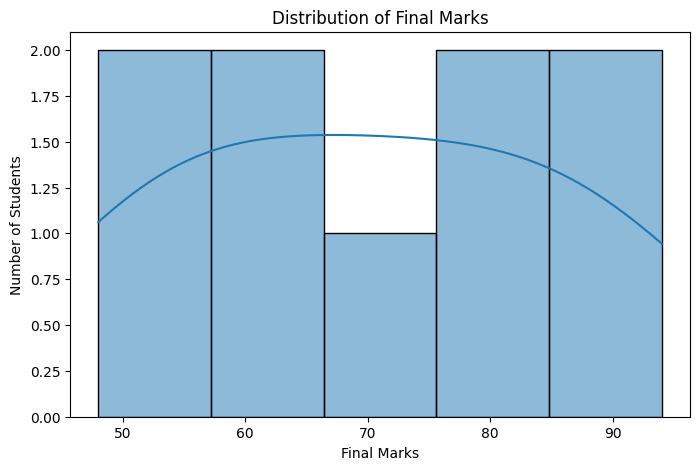

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["final_score"], kde=True)

plt.title("Distribution of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")

plt.show()


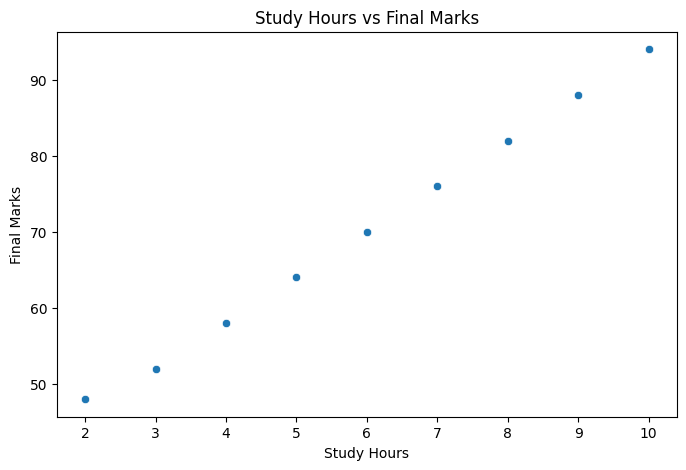

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="study_hours",
    y="final_score"
)

plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")

plt.show()


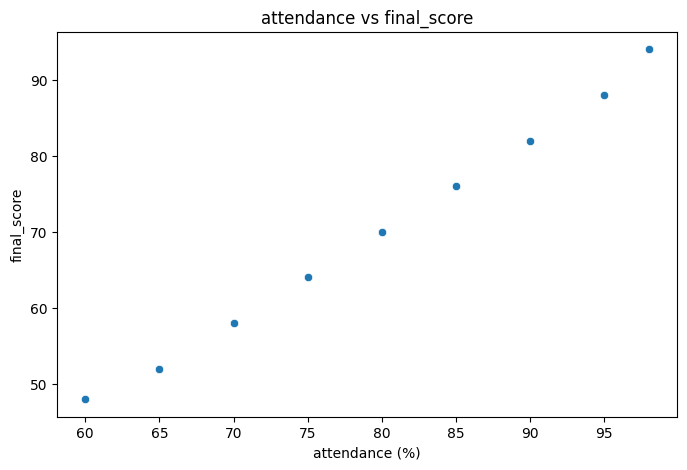

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="attendance",
    y="final_score"
)

plt.title("attendance vs final_score")
plt.xlabel("attendance (%)")
plt.ylabel("final_score")

plt.show()


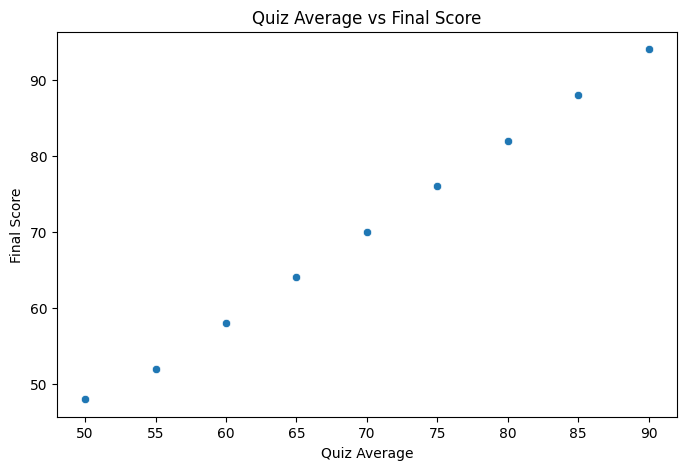

In [57]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="quiz_avg",
    y="final_score"
)

plt.title("Quiz Average vs Final Score")
plt.xlabel("Quiz Average")
plt.ylabel("Final Score")

plt.show()

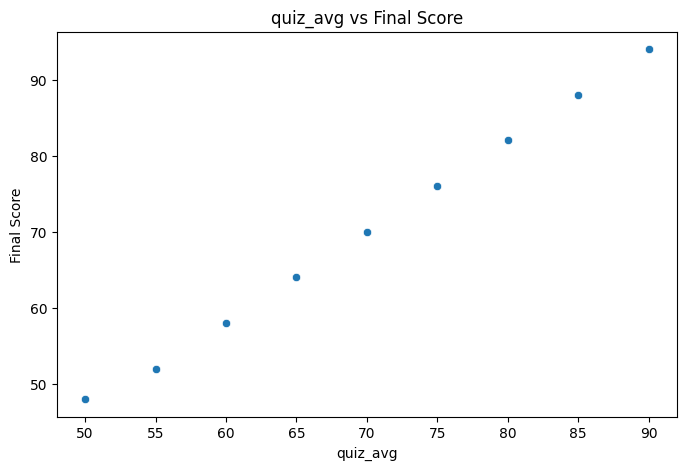

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="quiz_avg",
    y="final_score"
)

plt.title("quiz_avg vs Final Score")
plt.xlabel("quiz_avg")
plt.ylabel("Final Score")

plt.show()


In [27]:
correlation = df.corr(numeric_only=True)

print(correlation)


                study_hours  attendance  quiz_avg  assignment_avg   midterm  \
study_hours        1.000000    0.999125  1.000000        0.998140  1.000000   
attendance         0.999125    1.000000  0.999125        0.997236  0.999125   
quiz_avg           1.000000    0.999125  1.000000        0.998140  1.000000   
assignment_avg     0.998140    0.997236  0.998140        1.000000  0.998140   
midterm            1.000000    0.999125  1.000000        0.998140  1.000000   
final_score        0.999398    0.998161  0.999398        0.999219  0.999398   

                final_score  
study_hours        0.999398  
attendance         0.998161  
quiz_avg           0.999398  
assignment_avg     0.999219  
midterm            0.999398  
final_score        1.000000  


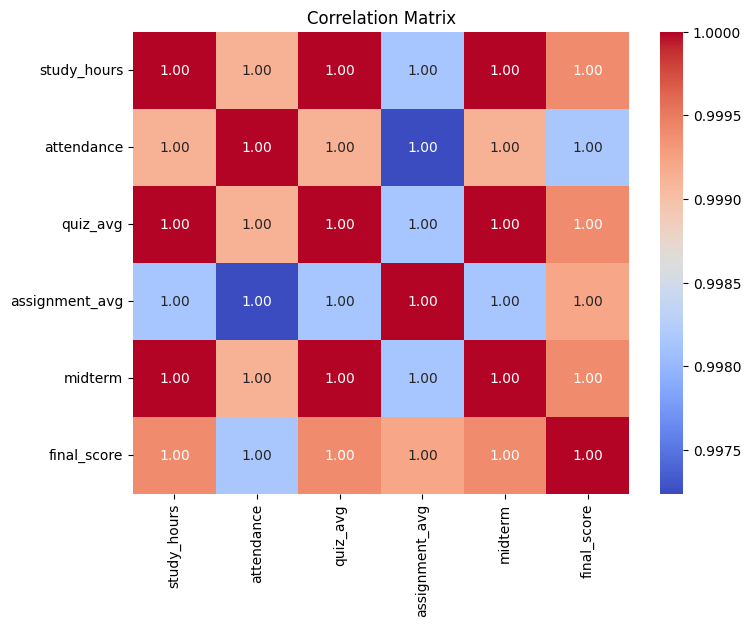

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Study Hours
Attendance
Previous Performance


In [30]:
X = df[
    [
        "study_hours",
        "attendance",
        "quiz_avg"
    ]
]

y = df["final_score"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   study_hours  attendance  quiz_avg
0            2          60        50
1            3          65        55
2            4          70        60
3            5          75        65
4            6          80        70

Target:
0    48
1    52
2    58
3    64
4    70
Name: final_score, dtype: int64


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7
Testing samples: 2


In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [33]:
print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)


Intercept: -2.3296703296702503

Coefficients:
study_hours : 0.31593406593406625
attendance : -0.5000000000000042
quiz_avg : 1.5796703296703334


Intercept = 8.52

Study Hours coefficient = 3.21
Attendance coefficient = 0.25
Previous Performance coefficient = 0.51

In [34]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred[:10])

Predicted values:
[87.28571429 53.        ]


In [35]:
comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

comparison.head(10)

,Actual Marks,Predicted Marks
0,88,87.285714
1,52,53.000000


In [36]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.8571428571428577
Mean Squared Error (MSE): 0.7551020408163294
Root Mean Squared Error (RMSE): 0.8689660757568901
R² Score: 0.9976694381456286


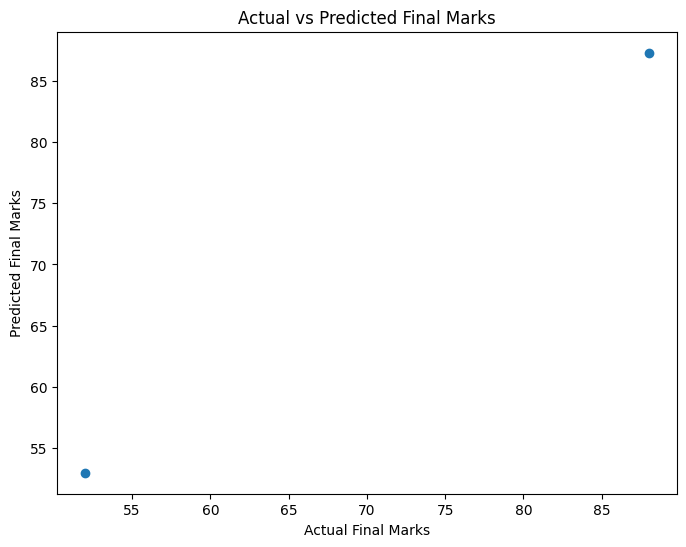

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")

plt.show()

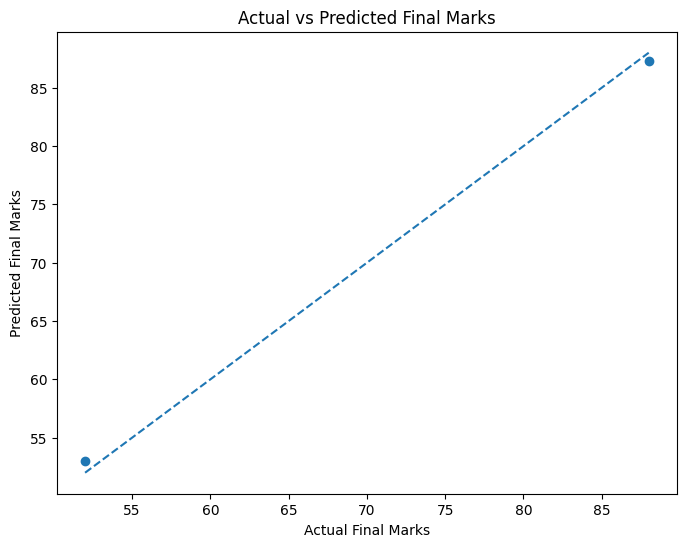

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Final Marks")

plt.show()

In [39]:
residuals = y_test - y_pred

print(residuals.head())

7    0.714286
1   -1.000000
Name: final_score, dtype: float64


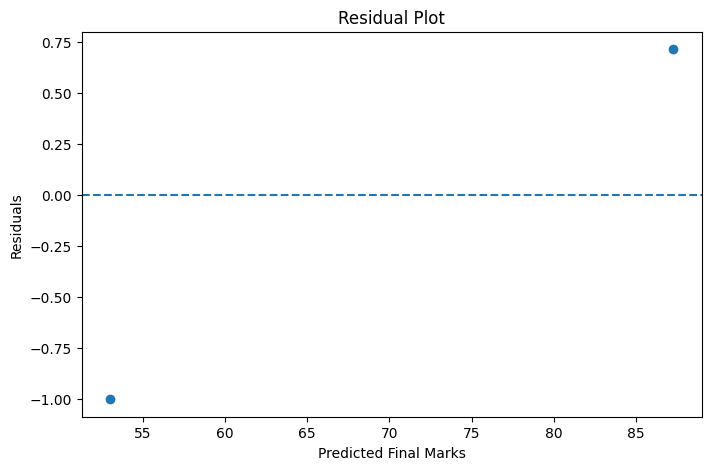

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Final Marks")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Study Hours = 7
Attendance = 90%
Previous Performance = 82

In [43]:
new_student = pd.DataFrame({
    "study_hours": [7],
    "attendance": [90],
    "quiz_avg": [82]
})

predicted_marks = model.predict(new_student)

print("Predicted Final Marks:", predicted_marks[0])

Predicted Final Marks: 84.41483516483518


In [45]:
def predict_final_marks(study_hours, attendance, previous_performance):

    student = pd.DataFrame({
        "study_hours": [study_hours],
        "attendance": [attendance],
        "quiz_avg": [quiz_avg]
    })

    prediction = model.predict(student)

    return prediction[0]

In [52]:
# Define the corrected function to fix the parameter mismatch (previous_performance -> quiz_avg)
def predict_final_marks(study_hours, attendance, quiz_avg):
    student = pd.DataFrame({
        "study_hours": [study_hours],
        "attendance": [attendance],
        "quiz_avg": [quiz_avg]
    })
    prediction = model.predict(student)
    return prediction[0]

# Call the correct function name
marks = predict_final_marks(8, 92, 85)
print("Predicted final score:", marks)

Predicted final score: 88.46978021978022


In [53]:
# Redefining the function with corrected parameter name
def predict_final_marks(study_hours, attendance, quiz_avg):
    student = pd.DataFrame({
        "study_hours": [study_hours],
        "attendance": [attendance],
        "quiz_avg": [quiz_avg]
    })
    prediction = model.predict(student)
    return prediction[0]

# Call the function with inputs
marks = predict_final_marks(8, 92, 85)
print("Predicted Final Marks:", marks)

Predicted Final Marks: 88.46978021978022


In [54]:
results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

results

,Metric,Value
0,MAE,0.857143
1,MSE,0.755102
2,RMSE,0.868966
3,R² Score,0.997669


In [55]:
comparison.to_csv(
    "student_prediction_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [56]:
from google.colab import files

files.download("student_prediction_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>